In [12]:
%load_ext autoreload 
%autoreload 2
import sys
sys.path.insert(1, '/Users/kevinlevy/Documents/cmb_cluster_lensing/files')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
from pylab import rcParams
from matplotlib import rc;rc('text', usetex=True);rc('font', weight='bold');matplotlib.rcParams['text.latex.preamble'] = r'\boldmath'
rcParams['font.family'] = 'serif'
rc('text.latex',preamble=r'\usepackage{/Users/kevinlevy/Documents/cmb_cluster_lensing/configs/apjfonts}')
color_arr =  ['firebrick', 'deepskyblue', 'seagreen']
from tqdm import tqdm
import cosmo
import lensing_estimator
import sims
import stats
import tools
import experiments as exp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
nber_clus = 2500
nber_rand = 50000
nber_runs = 20
map_params = [120, 0.5, 120, 0.5]
beam_fwhm = 1.0 # arcmin
noise_val_white = 2.0 # uK-arcmin
l = np.arange(10001)
cl = cosmo.cmb_power_spectra(l)['TT']
bl = exp.beam_power_spectrum(beam_fwhm, l)
noiseval_arr = [0.1, 0.5, 1., 3., 5., 7.]
nl_arr = []
cl_noise_arr = []
for noiseval in noiseval_arr:
    nl = exp.instrumental_noise_power_spectrum(noiseval, l)
    nl_deconvolved = exp.instrumental_noise_power_spectrum(noiseval,l, beam_fwhm = 1.0)
    nl_arr.append(nl)
    cl_noise_arr.append(nl_deconvolved)
z = 0.7
mass_int = np.arange(0, 4, 0.1)
M_input = 2e14

/Users/kevinlevy/Documents/cmb_cluster_lensing/files/cosmo.py:230: RuntimeWarning: divide by zero encountered in true_divide
  conv_fact = 2*np.pi/(l*(l+1))
/Users/kevinlevy/Documents/cmb_cluster_lensing/files/cosmo.py:231: RuntimeWarning: invalid value encountered in multiply
  cl_TT = dl_TT*conv_fact
/Users/kevinlevy/Documents/cmb_cluster_lensing/files/cosmo.py:232: RuntimeWarning: invalid value encountered in multiply
  cl_EE = dl_EE*conv_fact
/Users/kevinlevy/Documents/cmb_cluster_lensing/files/cosmo.py:233: RuntimeWarning: invalid value encountered in multiply
  cl_BB = dl_BB*conv_fact
/Users/kevinlevy/Documents/cmb_cluster_lensing/files/cosmo.py:234: RuntimeWarning: invalid value encountered in multiply
  cl_TE = dl_TE*conv_fact


In [3]:
#%%script false --no-raise-error
for i, noiseval in enumerate(noiseval_arr):
    covariance_matrix, correlation_matrix = lensing_estimator.covariance_and_correlation_matrix(nber_clus, nber_rand, map_params, l, cl,  cluster = [M_input, cosmo.concentration_parameter(M_input, z, 0.674), z], bl = bl, nl = nl_arr[i], cl_noise = cl_noise_arr[i])
    np.save('../results/covariance_matrix_1000sims_2500maps_1.0fwhm_'+str(noiseval)+'uK-arcmin.npy', covariance_matrix)
    np.save('../results/correlation_matrix_1000sims_2500maps_1.0fwhm_'+str(noiseval)+'uK-arcmin.npy', correlation_matrix)  

/Users/kevinlevy/Documents/cmb_cluster_lensing/files/lensing.py:81: RuntimeWarning: invalid value encountered in true_divide
  alphaX_fft =  1j * lX * 2. *  kappa_map_fft / l2d**2
/Users/kevinlevy/Documents/cmb_cluster_lensing/files/lensing.py:82: RuntimeWarning: invalid value encountered in true_divide
  alphaY_fft =  1j * lY * 2. *  kappa_map_fft / l2d**2
100%|██████████| 2500/2500 [2:31:20<00:00,  3.63s/it]  


In [44]:
#%%script false --no-raise-error
for i, noiseval in enumerate(noiseval_arr):
    models = lensing_estimator.models(nber_clus, map_params, l, cl, mass_int, z, bl = bl, cl_noise = cl_noise_arr[i], average = 10)
    np.save('../results/models_0e14to4e14_0.1e14steps_1.0fwhm_'+str(noiseval)+'uK-arcmin.npy', models) 

  0%|          | 0/10 [00:00<?, ?it/s]/Users/kevinlevy/Documents/cmb_cluster_lensing/files/lensing.py:151: RuntimeWarning: invalid value encountered in double_scalars
  r_s = r_200c/c_200c
/Users/kevinlevy/Documents/cmb_cluster_lensing/files/lensing.py:152: RuntimeWarning: invalid value encountered in double_scalars
  rho_s = (200./3.)*rho_c*(c_200c**3/(np.log(1+c_200c)-(c_200c/(1+c_200c))))
/Users/kevinlevy/Documents/cmb_cluster_lensing/files/lensing.py:81: RuntimeWarning: invalid value encountered in true_divide
  alphaX_fft =  1j * lX * 2. *  kappa_map_fft / l2d**2
/Users/kevinlevy/Documents/cmb_cluster_lensing/files/lensing.py:82: RuntimeWarning: invalid value encountered in true_divide
  alphaY_fft =  1j * lY * 2. *  kappa_map_fft / l2d**2
100%|██████████| 10/10 [2:50:40<00:00, 1024.03s/it] 


In [45]:
#%%script false --no-raise-error
now_save = []
now_save_comb = []
frac_mass_unc_arr = []
frac_mass_unc_results = ''
for i, noiseval in enumerate(noiseval_arr):
    likelihood_arr_noise = []
    for j in tqdm(range(nber_runs)): 
        covariance_matrix = np.load('../results/covariance_matrix_1000sims_2500maps_1.0fwhm_'+str(noiseval)+'uK-arcmin.npy')
        models = np.load('../results/models_0e14to4e14_0.1e14steps_1.0fwhm_'+str(noiseval)+'uK-arcmin.npy')
        maps_rand = sims.cmb_mock_data(map_params, l, cl,  bl = bl, nl = nl_arr[i], nber_obs = nber_rand)
        stack_bg = lensing_estimator.stack(map_params, maps_rand, l = l, cl = cl, cl_noise = cl_noise_arr[i])
        maps_clus = sims.cmb_mock_data(map_params, l, cl, cluster = [M_input, cosmo.concentration_parameter(M_input, z, 0.674), z], bl = bl, nl = nl_arr[i], nber_obs = nber_clus)
        stack_clus = lensing_estimator.stack(map_params, maps_clus, l = l, cl = cl, cl_noise = cl_noise_arr[i])   
        bins, lensing_dipole_profile, stack_dipole = lensing_estimator.lensing_dipole(map_params, stack_clus, stack_bg)  
        data = bins, lensing_dipole_profile, covariance_matrix         
        likelihood, mass_est, error = stats.run_ml(data, models, mass_int)
        likelihood_arr_noise.append(likelihood[1])  
        del maps_clus
    likelihood_comb, mass_est_comb, error_comb = stats.combined_likelihood(likelihood[0], likelihood_arr_noise) 
    now_save.append(likelihood_arr_noise)
    now_save_comb.append(likelihood_comb)
    frac_mass_unc_arr.append(error_comb/2)
    frac_mass_unc_results += "{0:11.3f}".format(error_comb/2) + "\n"

file = open('../results/fractional_mass_uncertainties_estimator_comparison.txt',"w")
file.write(frac_mass_unc_results)
file.close()

  0%|          | 0/20 [00:00<?, ?it/s]/Users/kevinlevy/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/minpack.py:476: RuntimeWarning: Number of calls to function has reached maxfev = 1000.
  warnings.warn(errors[info][0], RuntimeWarning)
100%|██████████| 20/20 [2:37:11<00:00, 471.56s/it]  
/Users/kevinlevy/Documents/cmb_cluster_lensing/files/stats.py:174: RuntimeWarning: divide by zero encountered in log
  comb_lk += np.log(likelihood_arr[i])
100%|██████████| 20/20 [2:30:31<00:00, 451.57s/it]  


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


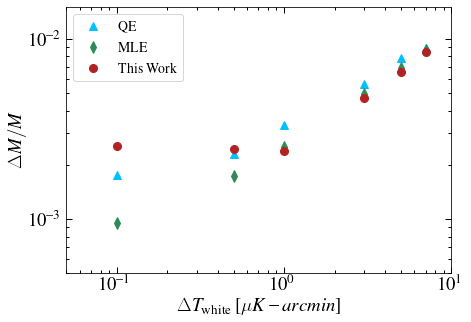

In [113]:
noiseval_arr = [0.1, 0.5, 1., 3., 5., 7.]
qe =  np.asarray([0.0175118, 0.02292831, 0.03323149, 0.05606527, 0.07843721, 0.08927969])*1e-1
mle = np.asarray([0.0095446, 0.01742045, 0.0251993, 0.04917473, 0.06890442, 0.0864266])*1e-1
scal_fac = np.sqrt(50000./100000.)
my = np.asarray(frac_mass_unc_arr)*scal_fac


fig, ax = plt.subplots( figsize=(6.9, 4.9))
ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(noiseval_arr, qe,  color = color_arr[1], ls = '', marker = '^', markersize = 8, label = 'QE')
ax.plot(noiseval_arr, mle,  color = color_arr[2], ls = '', marker = 'd',markersize = 8, label = 'MLE')
ax.plot(noiseval_arr, my,  color = color_arr[0], ls = '', marker = 'o',markersize = 8, label = 'This Work')
ax.set_xlabel(r'$\Delta T_{\rm white}\ [\mu K-arcmin]$', fontsize = 19)
ax.set_ylabel(r'$\Delta M/M$', fontsize = 19)
ax.tick_params(direction='in', axis='both', length=6, width=1, which = 'major', top = 'on', bottom = 'on', left = 'on', right = 'on', labelsize = 19)
ax.tick_params(direction='in', axis='both', length=3, width=1, which = 'minor', top = 'on', bottom = 'on', left = 'on', right = 'on', labelsize = 19)
ax.legend(ncol = 1, prop={'size': 14}, loc = 'upper left') 
ax.set_ylim(0.0005, 0.015)
ax.set_xlim(0.05, 10)
fig.savefig('../figures/estimator_comparison.eps', dpi = 200., bbox_inches = 'tight', pad_inches = 0.1)